# Backtester V2.1 configurable — hasta 12 valores y ventanas seleccionables

Versión con gráficos de operaciones reforzados y resumen de rentabilidad acumulada en porcentaje.

## Uso

1. En la celda **CONFIGURACIÓN**, deja sin `#` los activos que quieras ejecutar y comenta los demás.
2. Escribe el ticker de Yahoo Finance y el capital que quieras asignarle.
3. Activa de la misma manera las ventanas temporales deseadas.
4. Ejecuta todas las celdas.

Ejemplos: `META`, `SHOP`, `ITX.MC`, `BMW.DE`, `7203.T`, `MC.PA`, `ASML.AS`.

Los precios se normalizan a 100 para representar conjuntamente cotizaciones en dólares, euros o yenes. En el gráfico final, cada activo y el total parten de **0 %**, por lo que sus resultados son directamente comparables aunque tengan distintos capitales iniciales.

El cálculo usa precios ajustados por dividendos de forma predeterminada. No incluye comisiones, deslizamiento, impuestos, intereses del efectivo ni costes/disponibilidad del préstamo para posiciones cortas.


In [1]:
# ========================= CONFIGURACIÓN =========================
# Activa/desactiva cada línea añadiendo o quitando # al principio.
# Formato: ('TICKER_YAHOO', CAPITAL_ASIGNADO)
# Máximo: 12 valores activos.

ACTIVOS = [
    ('META',    5_000),
    ('SHOP',    5_000),
    # ('ITX.MC',  5_000),      # España
    # ('7203.T',  5_000),      # Toyota, Japón
    # ('7974.T',  5_000),      # Nintendo, Japón
    # ('BMW.DE',  5_000),      # Alemania
    # ('MC.PA',   5_000),      # LVMH, Francia
    # ('ASML.AS', 5_000),      # Países Bajos
    # ('AAPL',    5_000),
    # ('NVDA',    5_000),
    # ('MSFT',    5_000),
    # ('AMZN',    5_000),
]

# Activa únicamente las ventanas que quieras ver.
VENTANAS_MESES = [
    6,
    9
]
# Ejemplo para mostrar solo 3 y 9 meses:
# VENTANAS_MESES = [3, 9]

AJUSTAR_DIVIDENDOS = True
STOP_LONG = 0.07
STOP_SHORT = 0.07
PERIODO_RUPTURA = 20
MULTIPLICADOR_VOLUMEN = 1.00
RUPTURA_ATR = 2.0
RUPTURA_MAX_SESIONES = 20
# ================================================================


In [2]:
import warnings
import tempfile
from pathlib import Path
from dateutil.relativedelta import relativedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import yfinance as yf
from IPython import get_ipython
from IPython.display import display

warnings.filterwarnings('ignore')
yf.set_tz_cache_location(str(Path(tempfile.gettempdir()) / 'yf_backtester_v2_config_cache'))
ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic('matplotlib', 'inline')

if not 1 <= len(ACTIVOS) <= 12:
    raise ValueError('Debes activar entre 1 y 12 valores.')
tickers = [str(t).strip().upper() for t, _ in ACTIVOS]
capitales = {str(t).strip().upper(): float(c) for t, c in ACTIVOS}
if len(set(tickers)) != len(tickers):
    raise ValueError('No puede haber tickers duplicados en ACTIVOS.')
if any(c <= 0 for c in capitales.values()):
    raise ValueError('Todos los capitales deben ser mayores que cero.')
if not VENTANAS_MESES or any(not isinstance(m, int) or m <= 0 for m in VENTANAS_MESES):
    raise ValueError('VENTANAS_MESES debe contener enteros positivos.')
VENTANAS_MESES = sorted(set(VENTANAS_MESES))

max_meses = max(VENTANAS_MESES)
inicio_descarga = pd.Timestamp.today().normalize() - relativedelta(months=max_meses + 5)
datos_raw = {}
errores = []
for ticker in tickers:
    try:
        d = yf.download(ticker, start=inicio_descarga, interval='1d',
                        auto_adjust=AJUSTAR_DIVIDENDOS, progress=False, threads=False)
        if isinstance(d.columns, pd.MultiIndex):
            d.columns = d.columns.get_level_values(0)
        d = d[['Open', 'High', 'Low', 'Close', 'Volume']].dropna().copy()
        if getattr(d.index, 'tz', None) is not None:
            d.index = d.index.tz_localize(None)
        d.index = pd.to_datetime(d.index).normalize()
        d = d[~d.index.duplicated(keep='last')].sort_index()
        if len(d) < 60:
            raise ValueError(f'solo se recibieron {len(d)} sesiones')
        datos_raw[ticker] = d
    except Exception as exc:
        errores.append(f'{ticker}: {exc}')

if errores:
    raise RuntimeError('Error descargando datos:\n' + '\n'.join(errores))

ultima_fecha_comun = min(d.index.max() for d in datos_raw.values())
print('Valores activos:', ', '.join(f'{t} ({capitales[t]:,.2f})' for t in tickers))
print('Ventanas activas:', ', '.join(f'{m} meses' for m in VENTANAS_MESES))
print('Última fecha común:', ultima_fecha_comun.date())


Valores activos: META (5,000.00), SHOP (5,000.00)
Ventanas activas: 6 meses, 9 meses
Última fecha común: 2026-08-21


In [3]:
def preparar_senales(df):
    d = df.copy()
    delta = d['Close'].diff()
    subida, bajada = delta.clip(lower=0), -delta.clip(upper=0)
    rs = subida.rolling(14).mean() / bajada.rolling(14).mean()
    d['RSI'] = 100 - 100 / (1 + rs)
    d['BB_MIDDLE'] = d['Close'].rolling(20).mean()
    desviacion = d['Close'].rolling(20).std()
    d['BB_LOWER'] = d['BB_MIDDLE'] - 2 * desviacion
    d['EMA10'] = d['Close'].ewm(span=10, adjust=False).mean()
    cierre_previo = d['Close'].shift(1)
    tr = pd.concat([d['High'] - d['Low'],
                    (d['High'] - cierre_previo).abs(),
                    (d['Low'] - cierre_previo).abs()], axis=1).max(axis=1)
    d['ATR14'] = tr.ewm(alpha=1 / 14, adjust=False).mean()
    d['LONG_ENTRY'] = (d['RSI'] < 30) & (d['Close'] <= d['BB_LOWER'])
    d['LONG_EXIT'] = (d['RSI'] >= 65) | (d['Close'] >= d['BB_MIDDLE'])
    d['MINIMO_20_PREV'] = d['Low'].rolling(PERIODO_RUPTURA).min().shift(1)
    d['VOLUMEN_20_PREV'] = d['Volume'].rolling(PERIODO_RUPTURA).mean().shift(1)
    d['SHORT_RSI'] = d['RSI'] > 70
    d['SHORT_RUPTURA'] = ((d['Close'] < d['MINIMO_20_PREV']) &
                          (d['Volume'] > d['VOLUMEN_20_PREV'] * MULTIPLICADOR_VOLUMEN))
    return d


datos = {ticker: preparar_senales(d.loc[d.index <= ultima_fecha_comun])
         for ticker, d in datos_raw.items()}


In [4]:
def ejecutar_v2(ticker, fecha_inicio, capital_inicial):
    d = datos[ticker]
    fechas = d.index[(d.index >= fecha_inicio) & (d.index <= ultima_fecha_comun)]
    if len(fechas) < 2:
        raise ValueError(f'{ticker}: datos insuficientes para la ventana solicitada.')

    capital = float(capital_inicial)
    posicion = None
    operaciones, equity = [], []
    minimo_desde_entrada = trailing = np.inf
    sesiones = 0

    def cerrar(fecha, salida, motivo):
        nonlocal capital, posicion
        retorno = ((salida - posicion['Precio entrada']) / posicion['Precio entrada']
                   if posicion['Tipo'] == 'LONG'
                   else (posicion['Precio entrada'] - salida) / posicion['Precio entrada'])
        capital *= 1 + retorno
        operaciones.append({**posicion, 'Salida': fecha, 'Precio salida': salida,
                             'Rentabilidad %': retorno * 100, 'Motivo': motivo})
        posicion = None

    for fecha in fechas:
        i = d.index.get_loc(fecha)
        fila = d.iloc[i]
        senal = d.iloc[i - 1] if i > 0 else None
        apertura, maximo, minimo, cierre = map(float, [fila['Open'], fila['High'], fila['Low'], fila['Close']])
        estaba_abierta = posicion is not None

        if posicion is not None and senal is not None:
            entrada = posicion['Precio entrada']
            if posicion['Tipo'] == 'LONG':
                stop = entrada * (1 - STOP_LONG)
                if minimo <= stop:
                    cerrar(fecha, stop, 'STOP LOSS LONG')
                elif bool(senal['LONG_EXIT']):
                    cerrar(fecha, apertura, 'SEÑAL SALIDA LONG')
            elif posicion['Sistema entrada'] != 'RUPTURA':
                stop = entrada * (1 + STOP_SHORT)
                if maximo >= stop:
                    cerrar(fecha, stop, 'STOP LOSS SHORT')
                elif bool(senal['RSI'] < 50):
                    cerrar(fecha, apertura, 'SEÑAL SALIDA SHORT')
            else:
                sesiones += 1
                stop_activo = min(entrada * (1 + STOP_SHORT), trailing)
                recupera_ema = i >= 2 and bool((d['Close'].iloc[i-2:i] > d['EMA10'].iloc[i-2:i]).all())
                if maximo >= stop_activo:
                    cerrar(fecha, stop_activo, 'STOP/TRAILING RUPTURA')
                elif recupera_ema:
                    cerrar(fecha, apertura, 'DOS CIERRES SOBRE EMA10')
                elif bool(senal['RSI'] > 55):
                    cerrar(fecha, apertura, 'RSI > 55')
                elif sesiones >= RUPTURA_MAX_SESIONES:
                    cerrar(fecha, apertura, 'MÁXIMO 20 SESIONES')
                else:
                    minimo_desde_entrada = min(minimo_desde_entrada, cierre)
                    if pd.notna(fila['ATR14']):
                        trailing = min(trailing, minimo_desde_entrada + RUPTURA_ATR * float(fila['ATR14']))

        # No se abre una nueva operación en la misma apertura en que se cerró otra.
        if posicion is None and not estaba_abierta and senal is not None:
            if bool(senal['LONG_ENTRY']):
                posicion = {'Ticker': ticker, 'Tipo': 'LONG', 'Sistema entrada': 'RSI + BOLLINGER',
                            'Entrada': fecha, 'Precio entrada': apertura}
            elif bool(senal['SHORT_RUPTURA']):
                posicion = {'Ticker': ticker, 'Tipo': 'SHORT', 'Sistema entrada': 'RUPTURA',
                            'Entrada': fecha, 'Precio entrada': apertura}
            elif bool(senal['SHORT_RSI']):
                posicion = {'Ticker': ticker, 'Tipo': 'SHORT', 'Sistema entrada': 'RSI > 70',
                            'Entrada': fecha, 'Precio entrada': apertura}
            if posicion is not None:
                minimo_desde_entrada = apertura
                trailing = apertura * (1 + STOP_SHORT)
                sesiones = 0

        valor = capital
        if posicion is not None:
            entrada = posicion['Precio entrada']
            retorno_abierto = ((cierre - entrada) / entrada if posicion['Tipo'] == 'LONG'
                               else (entrada - cierre) / entrada)
            valor = capital * (1 + retorno_abierto)
        equity.append({'Fecha': fecha, 'Equity': valor})

    if posicion is not None:
        cerrar(fechas[-1], float(d.loc[fechas[-1], 'Close']), 'FIN DEL PERIODO')
        equity[-1]['Equity'] = capital

    eq = pd.DataFrame(equity).set_index('Fecha')
    dd = (eq['Equity'] / eq['Equity'].cummax() - 1).min() * 100
    return {'Ticker': ticker, 'Capital inicial': capital_inicial, 'Capital final': capital,
            'Rentabilidad %': (capital / capital_inicial - 1) * 100,
            'Drawdown máximo %': dd, 'Operaciones': operaciones, 'Equity': eq,
            'Fecha inicio': fechas[0], 'Fecha fin': fechas[-1]}


In [5]:
resultados = {}
filas = []

for meses in VENTANAS_MESES:
    fecha_objetivo = ultima_fecha_comun - relativedelta(months=meses)
    resultados[meses] = {}
    for ticker in tickers:
        r = ejecutar_v2(ticker, fecha_objetivo, capitales[ticker])
        resultados[meses][ticker] = r
        ops = pd.DataFrame(r['Operaciones'])
        filas.append({
            'Ventana (meses)': meses, 'Ticker': ticker,
            'Capital inicial': r['Capital inicial'], 'Capital final': r['Capital final'],
            'Beneficio': r['Capital final'] - r['Capital inicial'],
            'Rentabilidad %': r['Rentabilidad %'],
            'Drawdown máximo %': r['Drawdown máximo %'],
            'Operaciones': len(ops),
            'Acierto %': (ops['Rentabilidad %'].gt(0).mean() * 100 if not ops.empty else 0)
        })

    # Fila total ponderada por los capitales asignados.
    curvas = [r['Equity']['Equity'].rename(t) for t, r in resultados[meses].items()]
    total_eq = pd.concat(curvas, axis=1).sort_index().ffill().dropna().sum(axis=1)
    capital_total = sum(capitales.values())
    final_total = float(total_eq.iloc[-1])
    dd_total = (total_eq / total_eq.cummax() - 1).min() * 100
    filas.append({
        'Ventana (meses)': meses, 'Ticker': 'TOTAL CARTERA',
        'Capital inicial': capital_total, 'Capital final': final_total,
        'Beneficio': final_total - capital_total,
        'Rentabilidad %': (final_total / capital_total - 1) * 100,
        'Drawdown máximo %': dd_total,
        'Operaciones': sum(len(r['Operaciones']) for r in resultados[meses].values()),
        'Acierto %': np.nan
    })
    resultados[meses]['TOTAL CARTERA'] = {'Equity': total_eq.to_frame('Equity')}

tabla = pd.DataFrame(filas).set_index(['Ventana (meses)', 'Ticker'])
print('TABLA COMPARATIVA — SOLO VENTANAS Y VALORES ACTIVOS')
display(tabla.style.format({
    'Capital inicial': '{:,.2f}', 'Capital final': '{:,.2f}', 'Beneficio': '{:+,.2f}',
    'Rentabilidad %': '{:+.2f}%', 'Drawdown máximo %': '{:+.2f}%',
    'Acierto %': lambda x: '' if pd.isna(x) else f'{x:.1f}%'
}).apply(lambda fila: ['font-weight:bold;background-color:#fff3cd'] * len(fila)
         if fila.name[1] == 'TOTAL CARTERA' else [''] * len(fila), axis=1))


TABLA COMPARATIVA — SOLO VENTANAS Y VALORES ACTIVOS


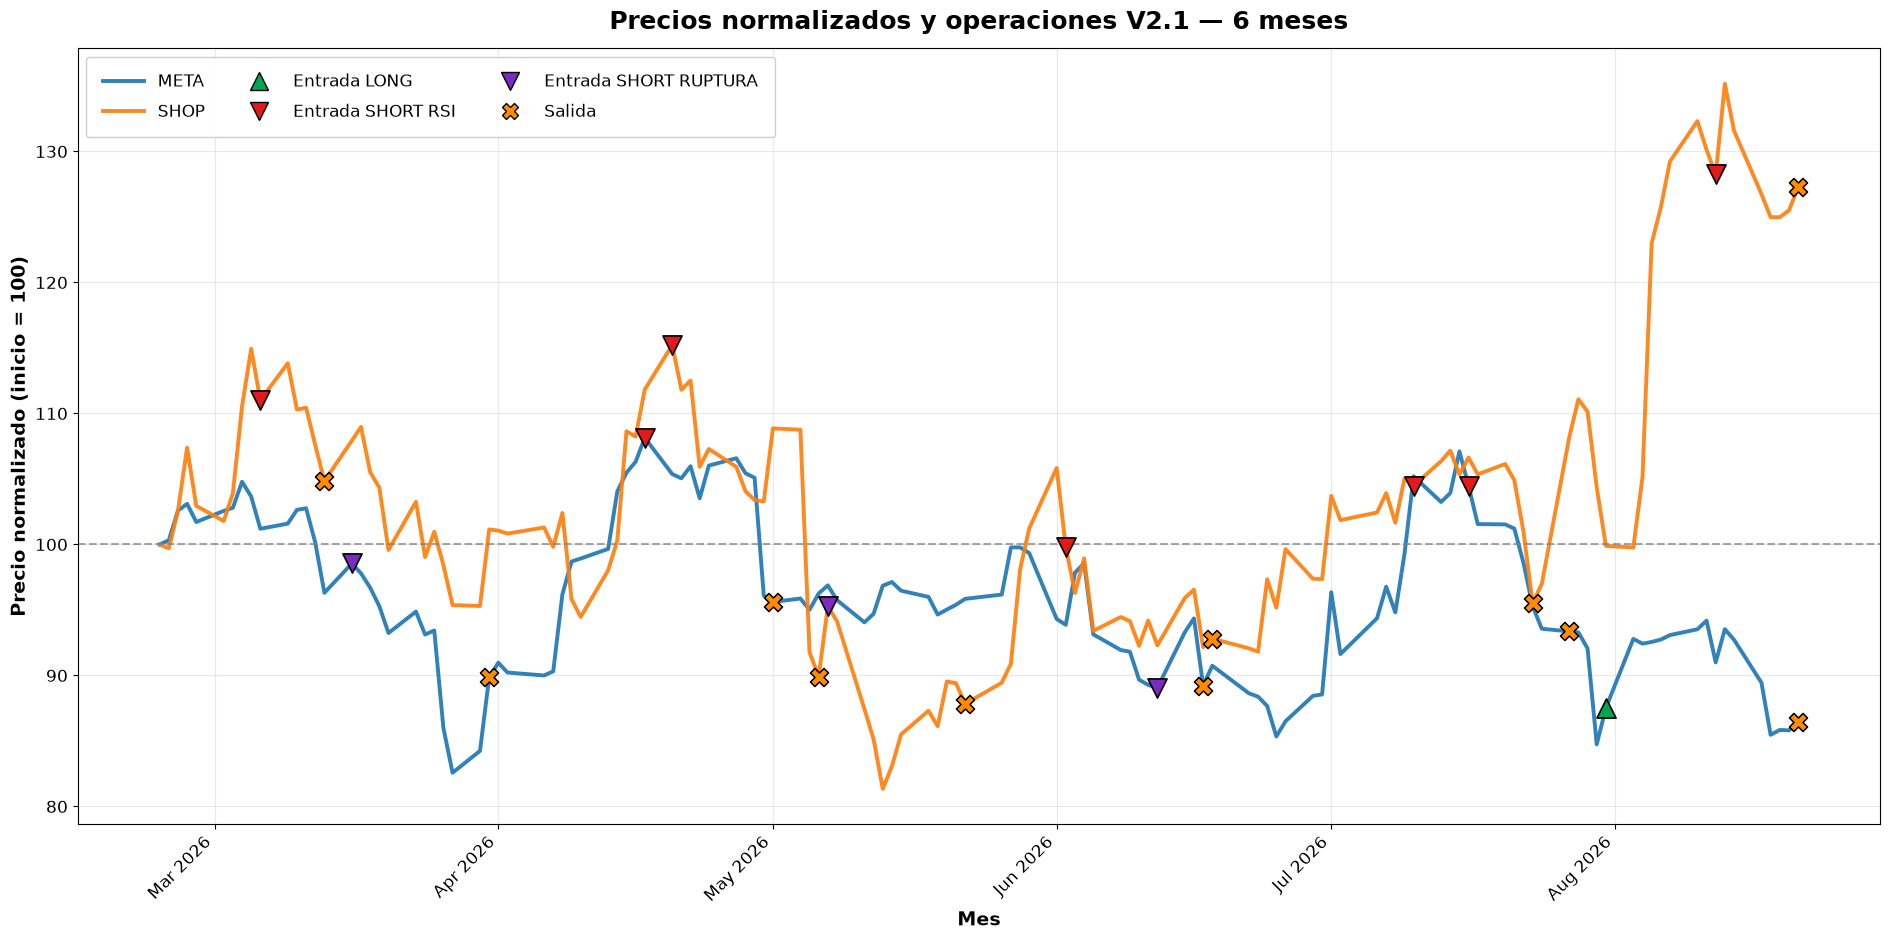

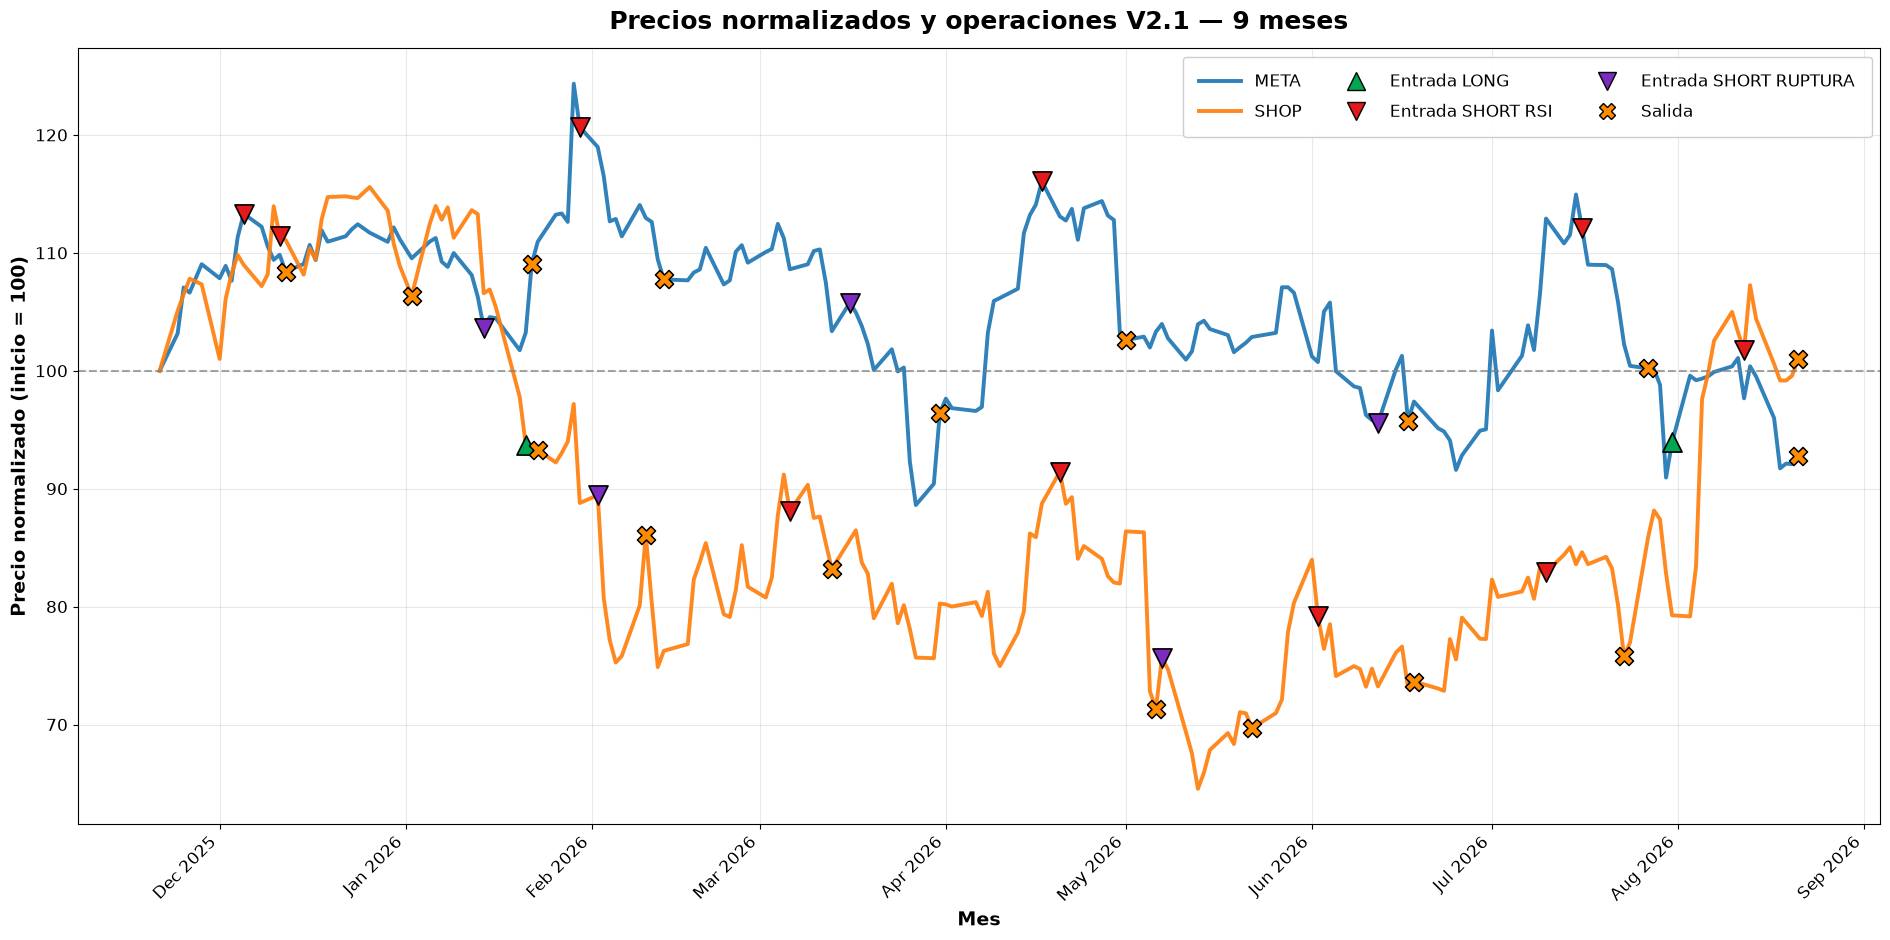

In [6]:
# Un color fijo por ticker para sus líneas de precio.
paleta = plt.get_cmap('tab10')
colores = {ticker: paleta(i % 10) for i, ticker in enumerate(tickers)}

# Colores semánticos, iguales en todas las ventanas y activos.
COLOR_LONG = '#00A651'
COLOR_SHORT_RSI = '#E31A1C'
COLOR_SHORT_RUPTURA = '#7B2CBF'
COLOR_SALIDA = '#FF8C00'

for meses in VENTANAS_MESES:
    fig, ax = plt.subplots(figsize=(19, 9.5))
    for ticker in tickers:
        r = resultados[meses][ticker]
        d = datos[ticker].loc[r['Fecha inicio']:r['Fecha fin']]
        normalizado = d['Close'] / d['Close'].iloc[0] * 100
        ax.plot(normalizado.index, normalizado, color=colores[ticker],
                lw=2.8, alpha=.92, label=ticker, zorder=2)

        for op in r['Operaciones']:
            if op['Entrada'] in normalizado.index:
                y_entrada = float(normalizado.loc[op['Entrada']])
                if op['Tipo'] == 'LONG':
                    color_entrada, marcador = COLOR_LONG, '^'
                elif op['Sistema entrada'] == 'RUPTURA':
                    color_entrada, marcador = COLOR_SHORT_RUPTURA, 'v'
                else:
                    color_entrada, marcador = COLOR_SHORT_RSI, 'v'
                ax.scatter(op['Entrada'], y_entrada, color=color_entrada,
                           marker=marcador, s=190, edgecolor='black', linewidth=1.2,
                           zorder=7)

            if op['Salida'] in normalizado.index:
                y_salida = float(normalizado.loc[op['Salida']])
                ax.scatter(op['Salida'], y_salida, color=COLOR_SALIDA,
                           marker='X', s=170, edgecolor='black', linewidth=1.1,
                           zorder=7)

    ax.axhline(100, color='gray', ls='--', lw=1.5, alpha=.7)
    ax.set_title(f'Precios normalizados y operaciones V2.1 — {meses} meses',
                 fontsize=18, fontweight='bold', pad=14)
    ax.set_xlabel('Mes', fontsize=14, fontweight='bold')
    ax.set_ylabel('Precio normalizado (inicio = 100)', fontsize=14, fontweight='bold')
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.grid(alpha=.28, linewidth=.8)
    ax.tick_params(axis='both', labelsize=12)

    handles, labels = ax.get_legend_handles_labels()
    handles += [
        Line2D([0], [0], marker='^', color='w', markerfacecolor=COLOR_LONG,
               markeredgecolor='black', markersize=13, label='Entrada LONG'),
        Line2D([0], [0], marker='v', color='w', markerfacecolor=COLOR_SHORT_RSI,
               markeredgecolor='black', markersize=13, label='Entrada SHORT RSI'),
        Line2D([0], [0], marker='v', color='w', markerfacecolor=COLOR_SHORT_RUPTURA,
               markeredgecolor='black', markersize=13, label='Entrada SHORT RUPTURA'),
        Line2D([0], [0], marker='X', color='w', markerfacecolor=COLOR_SALIDA,
               markeredgecolor='black', markersize=12, label='Salida')
    ]
    ax.legend(handles=handles, loc='best', ncol=min(3, len(handles)),
              fontsize=12, framealpha=.96, borderpad=1.0,
              handlelength=2.5, labelspacing=.8)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    display(fig)
    plt.close(fig)


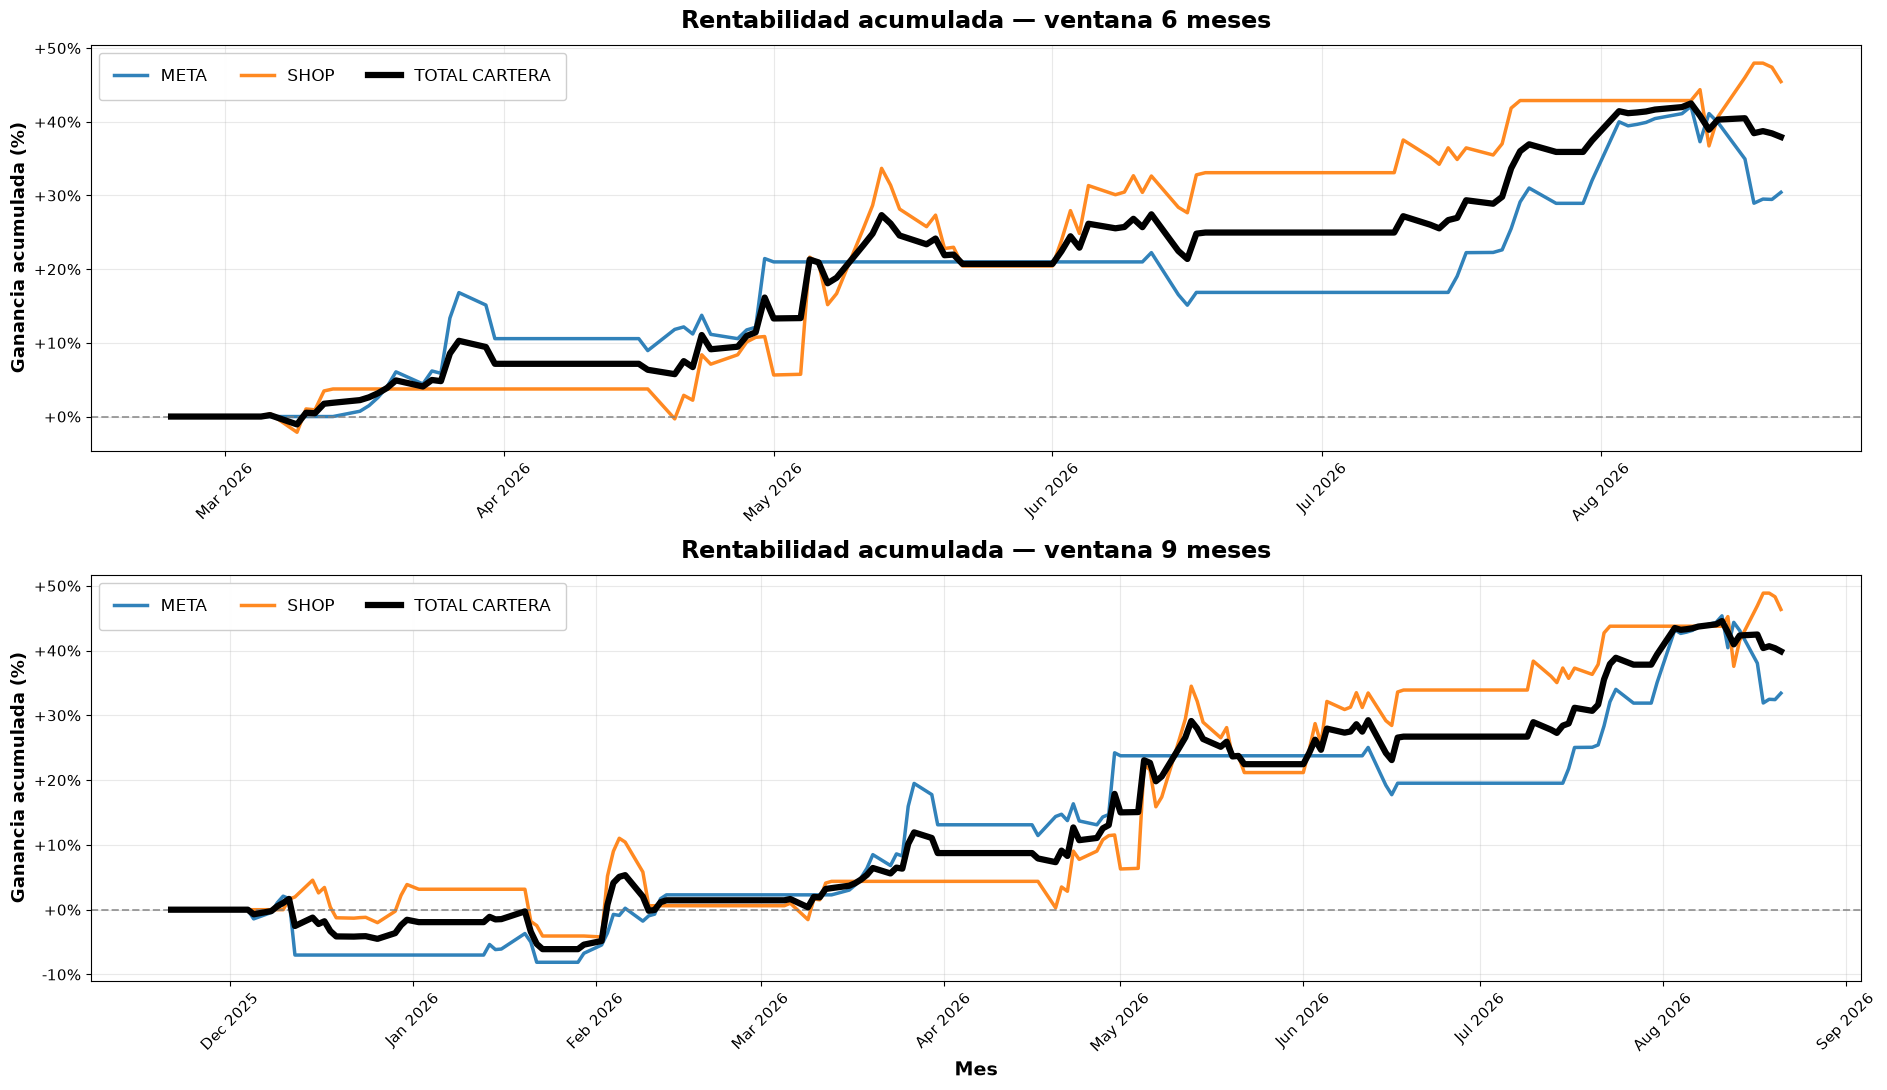

In [7]:
# Resumen final en RENTABILIDAD ACUMULADA (%).
# Todos los activos y la cartera total parten del mismo nivel: 0 %.
n = len(VENTANAS_MESES)
fig, axes = plt.subplots(n, 1, figsize=(19, max(7, 5.5 * n)), squeeze=False)

for ax, meses in zip(axes[:, 0], VENTANAS_MESES):
    for ticker in tickers:
        eq = resultados[meses][ticker]['Equity']['Equity']
        rentabilidad = (eq / capitales[ticker] - 1) * 100
        ax.plot(rentabilidad.index, rentabilidad, color=colores[ticker],
                lw=2.5, alpha=.92, label=ticker)

    capital_total_inicial = sum(capitales.values())
    total = resultados[meses]['TOTAL CARTERA']['Equity']['Equity']
    rentabilidad_total = (total / capital_total_inicial - 1) * 100
    ax.plot(rentabilidad_total.index, rentabilidad_total,
            color='black', lw=4.5, label='TOTAL CARTERA', zorder=6)

    ax.axhline(0, color='gray', ls='--', lw=1.4, alpha=.75)
    ax.set_title(f'Rentabilidad acumulada — ventana {meses} meses',
                 fontsize=17, fontweight='bold', pad=12)
    ax.set_ylabel('Ganancia acumulada (%)', fontsize=13, fontweight='bold')
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:+.0f}%'))
    ax.grid(alpha=.28, linewidth=.8)
    ax.legend(loc='best', ncol=min(4, len(tickers) + 1),
              fontsize=12, framealpha=.96, borderpad=.9)
    ax.tick_params(axis='both', labelsize=11)
    ax.tick_params(axis='x', rotation=45)

axes[-1, 0].set_xlabel('Mes', fontsize=14, fontweight='bold')
plt.tight_layout()
display(fig)
plt.close(fig)


## Interpretación y límites

- Cada activo utiliza únicamente el capital asignado en `ACTIVOS`; no se rebalancea ni transfiere dinero entre valores.
- Un activo puede tener una posición abierta al mismo tiempo que los demás.
- El resumen porcentual divide cada curva por su propio capital inicial. La línea negra divide el total por la suma de todos los capitales asignados.
- Los rendimientos se calculan en la moneda local de cada cotización. La fila total no incorpora fluctuaciones de divisa.
- El modelo admite fracciones teóricas de acciones; no comprueba lotes mínimos, margen ni disponibilidad para cortos.
- Los resultados históricos no garantizan rendimientos futuros.
